In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import numpy as np
import pandas as pd
from scipy import linalg as la
from koala import plotting as pl
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_spin_per_state,
    spectral_function,
)
from alter_morph.lattice_utilities import alter_lattice_maker
from alter_morph.hamiltonians import _hopping_matrix
from alter_morph.mean_field import hartree_fock, single_hartree_fock_step

import tqdm
import seaborn as sns

# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [12]:
# generate the lattice and set the initial conditions

import koala.graph_utils


system_length = 8
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
# lattice = koala.graph_utils.cut_boundaries(lattice)

t1 = -1
t2 = -0.5

n_J = 100
J_values = np.linspace(0.1, 0.6, n_J)
U_value = 0
filling = 0.8
initial_m = np.full(lattice.n_vertices, 1) + 0.001 * np.random.rand(lattice.n_vertices)
initial_n = np.full(lattice.n_vertices, filling * 4)
theta_offset = 0.0

In [13]:
from time import time

current_m = initial_m

start = time()

m_out = []
n_out = []
e_out = []
s_out = []


for J in tqdm.tqdm(J_values):

    initial_parameters = {
        "t1": t1,
        "t2": t2,
        "J": J,
        "U": J,
        "filling": filling,
        # "initial_m": current_m + 0.001 * np.random.rand(lattice.n_vertices),
        "initial_m": initial_m,
        "initial_n": initial_n,
        "theta_offset": theta_offset,
    }

    m_values, n_values = hartree_fock(
        lattice,
        initial_parameters,
        40,
        mixing_proportion=0.5,
        tol_mdiff=0.001,
        verbose=False,
    )

    hamiltonian = alt_hamiltonian(
        lattice,
        initial_parameters["t1"],
        initial_parameters["t2"],
        initial_parameters["J"],
        initial_parameters["U"],
        m_values[-1],
        n_values[-1],
        theta_offset=initial_parameters["theta_offset"],
    )
    energies, states = la.eigh(hamiltonian)

    current_m = m_values[-1]
    current_n = n_values[-1]

    m_out.append(current_m)
    n_out.append(current_n)
    e_out.append(energies)
    s_out.append(states)


end = time()
print(f"Time taken: {end - start:.2f} s")

100%|██████████| 100/100 [00:45<00:00,  2.18it/s]

Time taken: 45.93 s


In [14]:
hamiltonian = alt_hamiltonian(
    lattice,
    initial_parameters["t1"],
    initial_parameters["t2"],
    initial_parameters["J"],
    initial_parameters["U"],
    m_values[-1],
    n_values[-1],
    theta_offset=initial_parameters["theta_offset"],
)

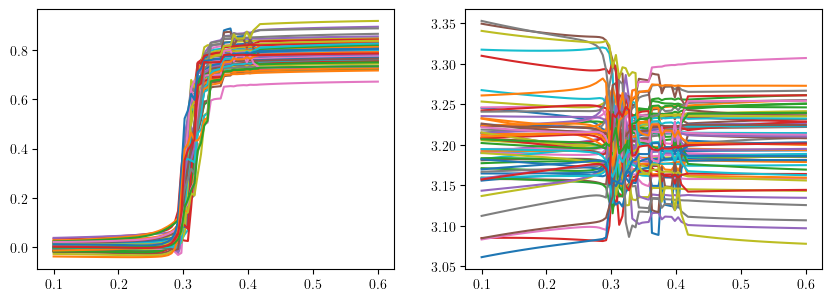

In [15]:
# Time taken: 182.64 s

fig, ax = plt.subplots(1, 2, figsize=(aps_halfwidth * 3, aps_halfwidth))

ax[0].plot(J_values, m_out)
ax[1].plot(J_values, n_out)
plt.show()

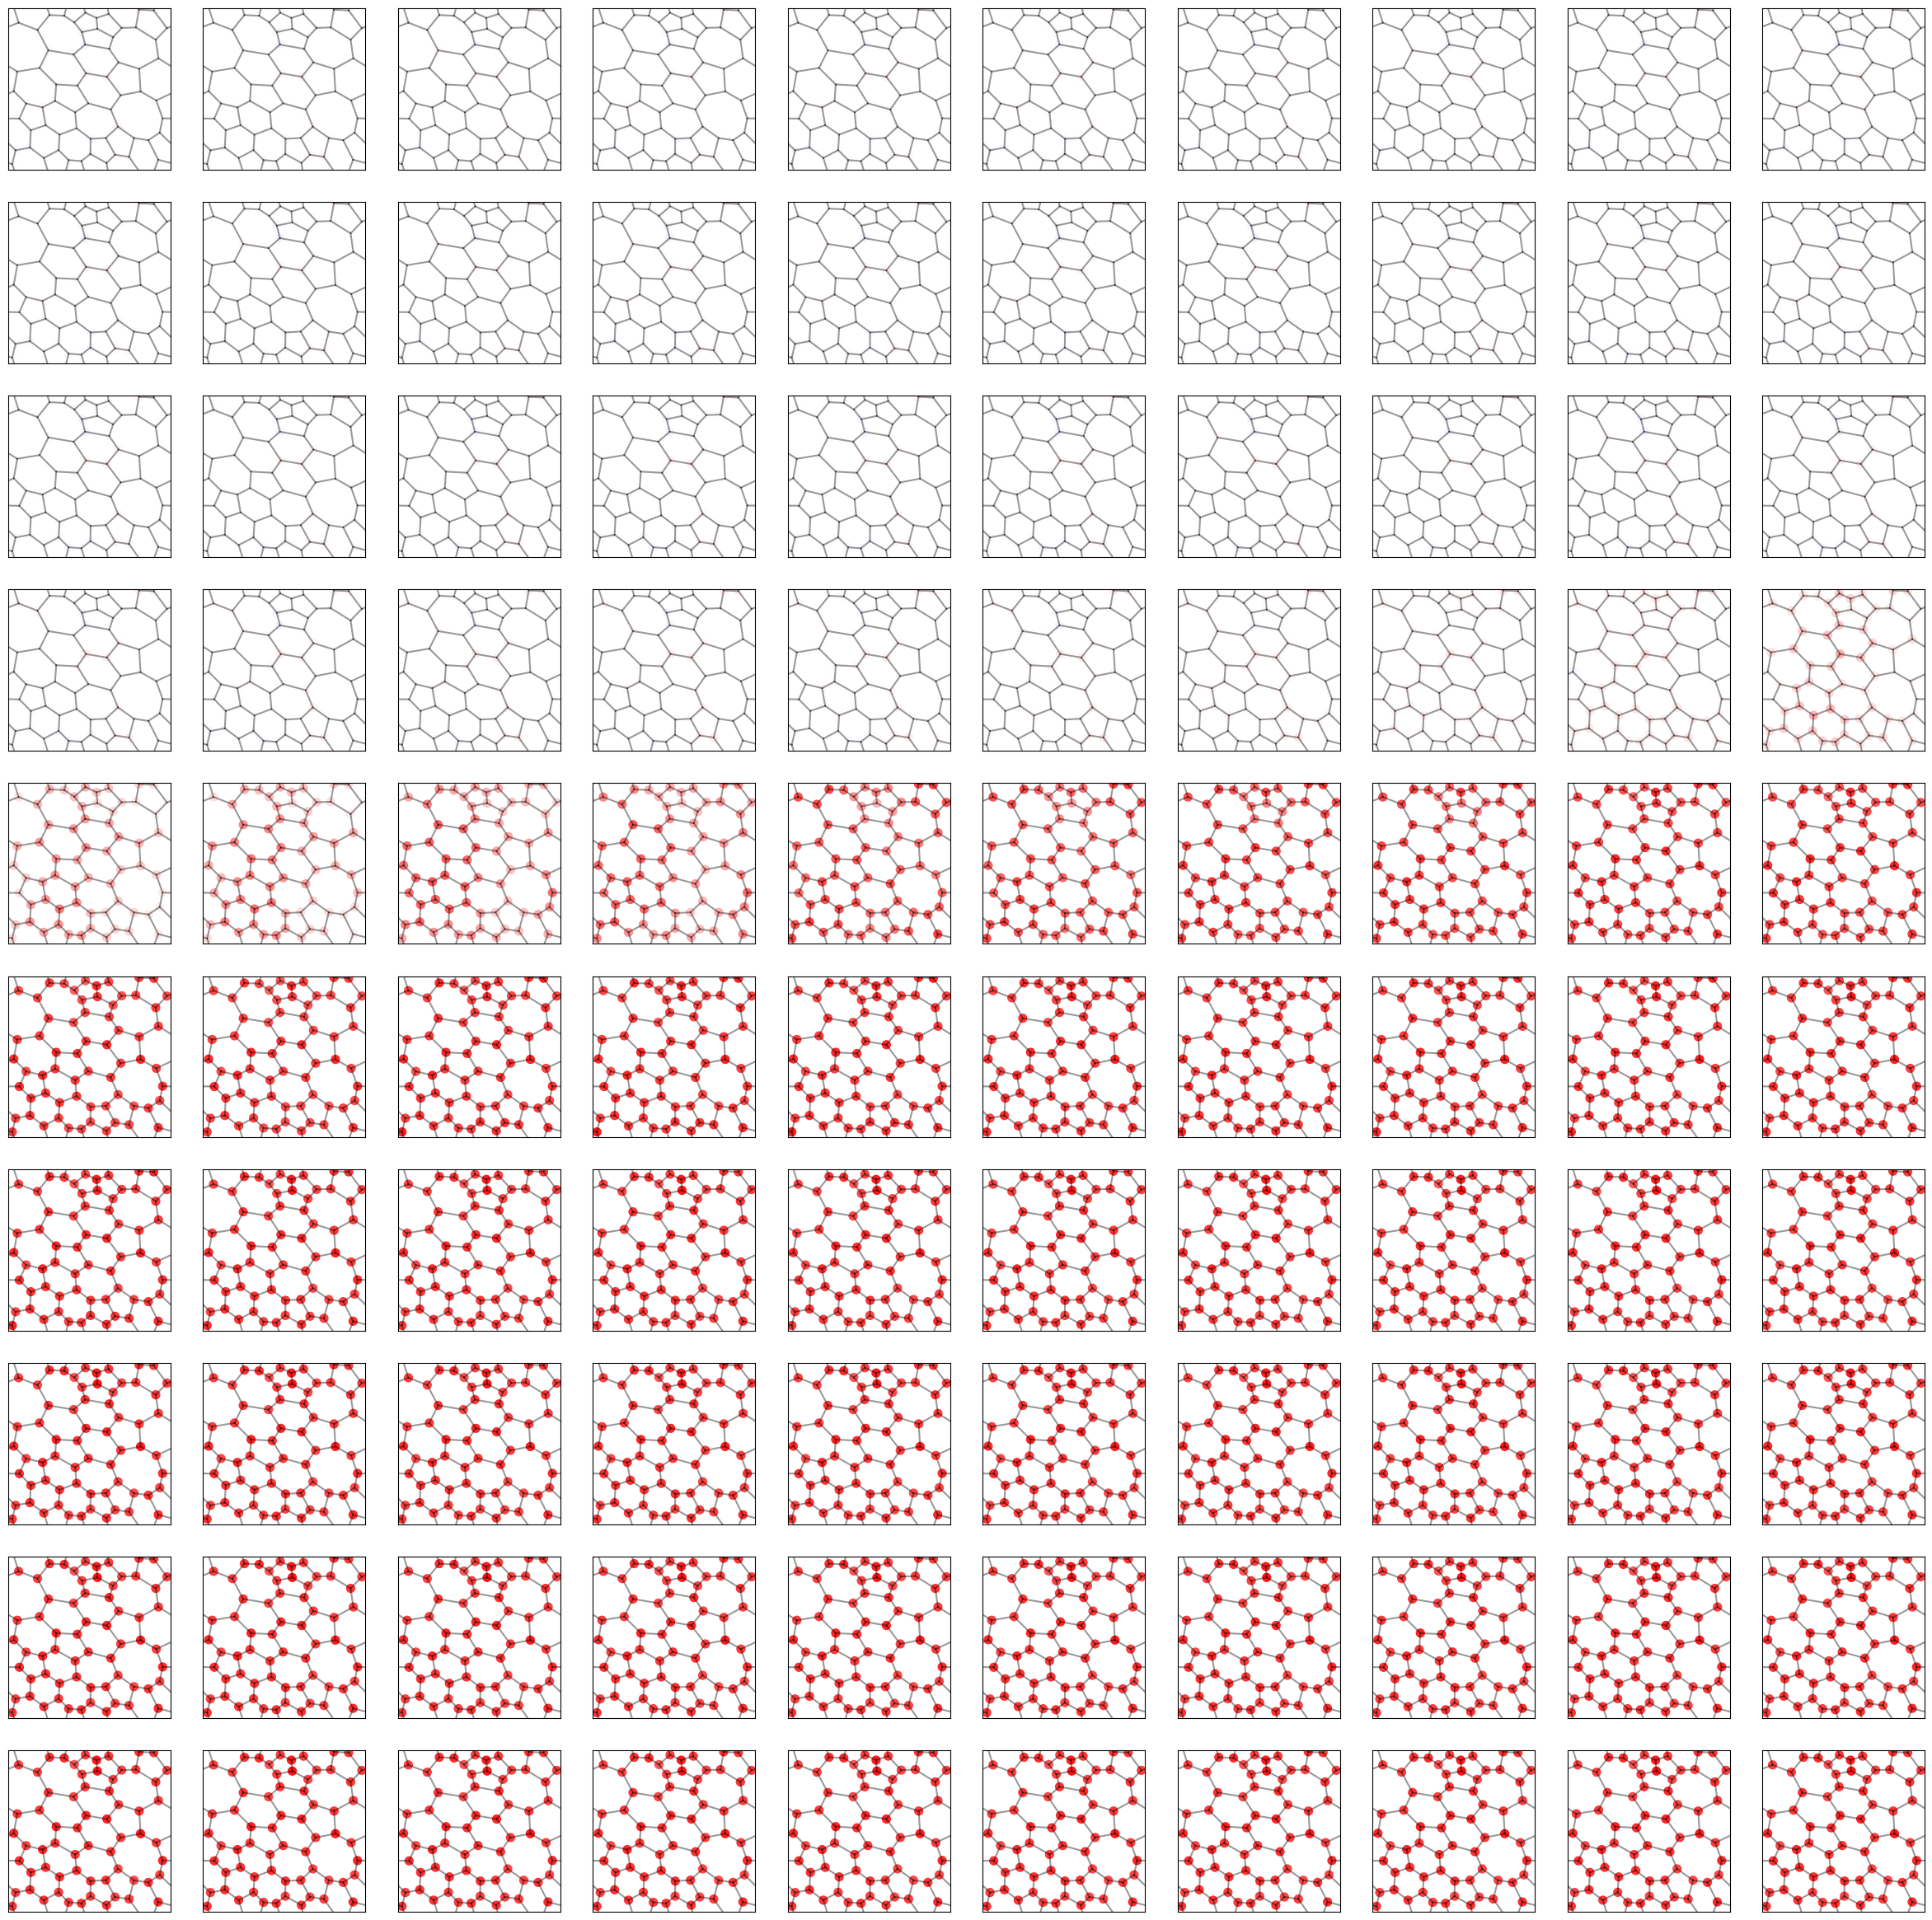

In [16]:
fig, ax = plt.subplots(len(J_values) // 10, 10, figsize=(30, 3 * (len(J_values) // 10)))
ax = ax.flatten()
# m_out = np.array(m_out)[::-1]
for i in range(len(J_values)):
    pl.plot_edges(lattice, ax=ax[i], alpha=0.4)
    im = ax[i].scatter(
        lattice.vertices.positions[:, 0],
        lattice.vertices.positions[:, 1],
        c=m_out[i],
        cmap="bwr",
        s=50,
        vmin=-1,
        vmax=1,
    )
    # get rid of the axis labels
    ax[i].set_xticks([])
    ax[i].set_yticks([])

In [17]:
e_out = np.array(e_out)
s_out = np.array(s_out)

# e_out.shape, s_out.shape, j_list.shape

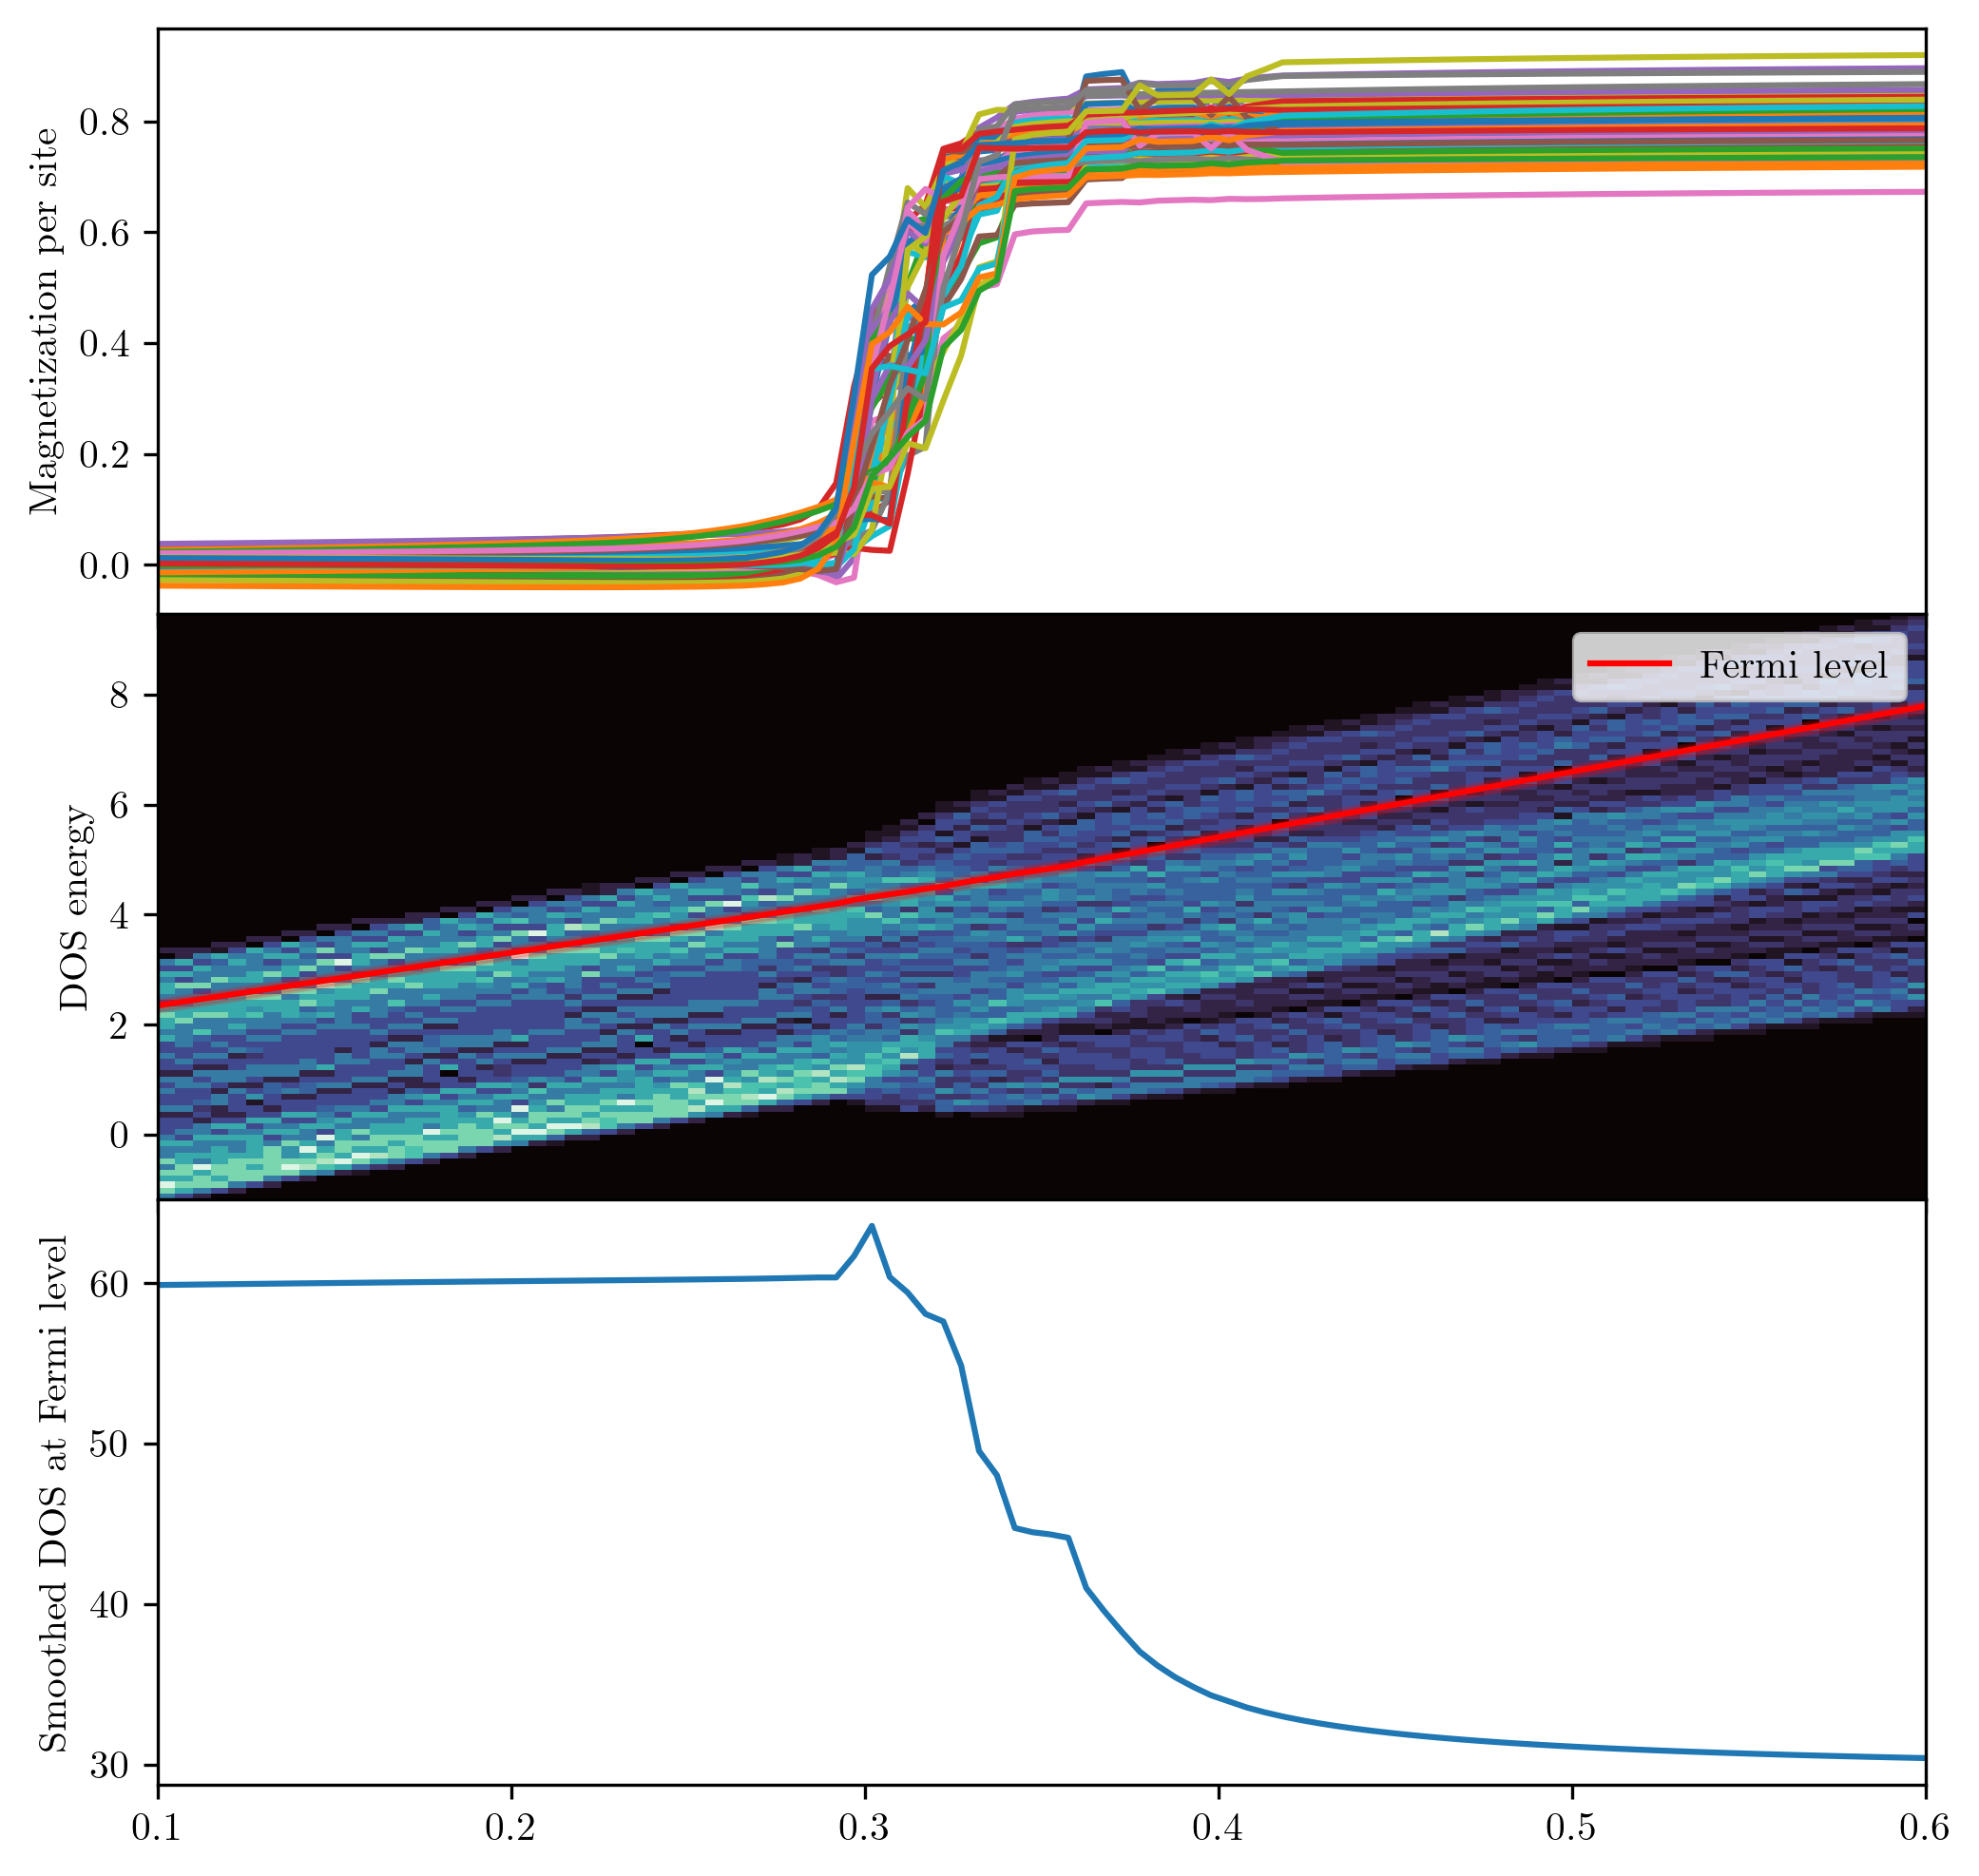

In [ ]:
j_list = (np.array([J_values] * e_out.shape[1]).T).flatten()

std_dev = 0.1
fermi_out = []
smoothed_density_at_fermi_level = []
for e in e_out:
    fermi_level = np.mean(
        np.sort(e)[
            int(filling * lattice.n_vertices * 4 - 1) : 1
            + int(filling * lattice.n_vertices * 4)
        ]
    )
    fermi_out.append(fermi_level)

    norm_gaussian = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((e - fermi_level) / std_dev) ** 2
    )

    norm_lorenzian = (1 / np.pi) * (std_dev / ((e - fermi_level) ** 2 + std_dev**2))

    smoothed_density_at_fermi_level.append(np.sum(norm_lorenzian))


data = pd.DataFrame(
    {
        "J": j_list,
        "energy": e_out.flatten(),
    }
)

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True, dpi=300)
fig.subplots_adjust(hspace=0)
ax[0].plot(J_values, m_out)
ax[1].hist2d(j_list, e_out.flatten(), bins=[100, 100], cmap="mako")
ax[1].plot(J_values, fermi_out, color="red", label="Fermi level")

# shade between the fermi level and the fermi level +/ std_dev
ax[1].fill_between(
    J_values,
    np.array(fermi_out) - std_dev,
    np.array(fermi_out) + std_dev,
    color="red",
    alpha=0.2,
)

ax[2].plot(J_values, smoothed_density_at_fermi_level)


ax[0].set_ylabel("Magnetization per site")
ax[1].set_ylabel("DOS energy")
ax[2].set_ylabel("Smoothed DOS at Fermi level")

ax[1].legend()
plt.show()